## **Medical Imaging & Big Data**
### **Master's Degree in Data Science**
University of Milano - Bicocca

Induni Sandapiumi Nawarathna Pitiyage - 906451

Sara Campolattano - 906453

In [ ]:
!pip install nibabel

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# you don't need this outside Google COLAB

#!pip install -U tensorboard-plugin-profile
# !pip install nibabel
#set up imports
# previousl line only needed when working in google COLAB
import matplotlib
#matplotlib.use('Agg')
import glob
import os
import numpy as np
import nibabel as nib
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Conv2D, Activation, BatchNormalization, MaxPooling2D, concatenate, Conv2DTranspose, UpSampling2D, SeparableConv2D
from tensorflow.keras.layers import ZeroPadding2D,Add,ReLU,AveragePooling2D
from tensorflow.keras import metrics as mtt
from tensorflow.keras import optimizers
import math
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import random

In [ ]:
#import os
#import glob
#import shutil

# Source paths
#base_path = "/content/drive/MyDrive/Colab Notebooks/Exercise/es3-Radiomics-BRATS"
#lgg_path = os.path.join(base_path, "Pre-operative_TCGA_LGG_NIfTI_and_Segmentations")
#gbm_path = os.path.join(base_path, "Pre-operative_TCGA_GBM_NIfTI_and_Segmentations")

# Destination path
#base_path_1 = "/content/drive/MyDrive/Colab Notebooks/Medical_Imaging"
#merged_path = os.path.join(base_path_1, "Merged_BRATS_Data")
#os.makedirs(merged_path, exist_ok=True)

# Function to copy all patient folders
#def copy_all_patients(src_folder, dest_folder, prefix):
#    patient_dirs = glob.glob(os.path.join(src_folder, "*"))
#    for path in patient_dirs:
#        if os.path.isdir(path):
#            folder_name = os.path.basename(path)
#            new_folder_name = f"{prefix}_{folder_name}"
#            dest_path = os.path.join(dest_folder, new_folder_name)
#            if not os.path.exists(dest_path):
#                shutil.copytree(path, dest_path)
#                print(f"Copied: {path} -> {dest_path}")
#            else:
#               print(f"Skipped (already exists): {dest_path}")
#        else:
#            print(f"Skipped (not a folder): {path}")

# Copy LGG and GBM patient folders
#copy_all_patients(lgg_path, merged_path, prefix="LGG")
#copy_all_patients(gbm_path, merged_path, prefix="GBM")


In [3]:
base_path_1 = "/content/drive/MyDrive/Colab Notebooks/Medical_Imaging"
# Glob all truth label files (ground truths)
fileL = glob.glob(os.path.join(base_path_1, "Merged_BRATS_Data", "*", "truth.nii.gz"))

print("Number of labeled images found:", len(fileL))

Number of labeled images found: 167


In [4]:
nPatAn = 70
nChan=4
chanNames = {1:'t1.nii.gz',2:'t1ce.nii.gz',3:'flair.nii.gz',0:'t2.nii.gz'}

In [5]:
immV = np.zeros((nPatAn,120,120,77,nChan),dtype=np.float32)
# Preallocate the array for segmentation labels (binary masks), same dimensions but 1 channel
segV = np.zeros((nPatAn,120,120,77,1),dtype=np.float32)

In [6]:
# Load and Downsample Data
# Iterate over the first 60 patient segmentation files (truth.nii.gz).
# For each patient:
#  Load each MRI channel (t1, t1ce, flair, t2).
#  Reshape and downsample using 3D block reduction: from original resolution to 120x120x77 using reshape and then np.mean over certain axes.
#  Store the downsampled MRI data into immV.
#  Load and downsample the segmentation mask (truth.nii.gz) using np.max instead of mean, ensuring binary segmentation labels are preserved.

for pIdx,fN in enumerate(fileL[:nPatAn]):
    pDir = os.path.dirname(fN)
    for chanL in chanNames.keys():
        iHead = nib.load(os.path.join(pDir,chanNames[chanL]))
        iTemp = iHead.get_fdata(dtype=np.float32)
        iTemp = iTemp[:,:,1:].reshape((2,120,2,120,2,77),order='F')
        immV[pIdx,:,:,:,chanL]= np.mean(np.mean(np.mean(iTemp,axis=-2),axis=-3),axis=0)
    iHead = nib.load(fN)
    iTemp = iHead.get_fdata(dtype=np.float32)
    iTemp = iTemp[:,:,1:].reshape((2,120,2,120,2,77),order='F')
    segV[pIdx,:,:,:,0]= np.max(np.max(np.max(iTemp,axis=-2),axis=-3),axis=0)

nerj

## Scale image intensities

In [7]:
# Normalization & Label Formatting
# Normalize each channel per subject using robust statistics:
# Ignores bottom 1% of intensities (noise/outliers).
# Uses 50th percentile (median) of the remaining values for scaling.
# This normalization centers data around 0 and scales it based on median intensity, improving model convergence.

intVal = np.zeros((immV.shape[0],nChan),dtype=np.float32)
for sub in range(immV.shape[0]):
  for chan in range(nChan):
    iTemp = np.squeeze(immV[sub,:,:,:,chan])
    lThr = np.percentile(iTemp,1)
    intVal[sub,chan]=np.percentile(iTemp[iTemp>lThr],50)
intVal = intVal.reshape((immV.shape[0],1,1,1,nChan))
immV = (immV-0.5*intVal)/intVal

# Prepare segmentation labels:
#  Caps segmentation labels at 3 (likely the max valid class).
# Converts segmentation volumes into one-hot encoded format (needed for categorical_crossentropy).

segV[segV>3.5]=3
segV = tf.keras.utils.to_categorical(segV)

In [8]:
from sklearn.model_selection import train_test_split

# Split into training and testing (e.g., 67% train, 33% test)
X_train, X_test, y_train, y_test = train_test_split(
    immV, segV, test_size=0.33, random_state=42
)

# Split 40% of training data for data augmentation
X_train_main, X_aug, y_train_main, y_aug = train_test_split(
    X_train, y_train, test_size=0.50, random_state=42 #changing to 50%
)

In [9]:
print("Number of patients in training set:", X_train.shape[0])
print("Number of patients in test set:", X_test.shape[0])
print("Number of patients used for data augumentation set:", X_aug.shape[0])

Number of patients in training set: 46
Number of patients in test set: 24
Number of patients used for data augumentation set: 23


In [10]:
# Reshape for 2D Training
X_train_main = X_train_main.transpose((0,3,1,2,4))
X_train_main = X_train_main.reshape((-1,120,120,4))
y_train_main = y_train_main.transpose((0,3,1,2,4))
y_train_main = y_train_main.reshape((-1,120,120,4))

X_aug = X_aug.transpose((0,3,1,2,4))
X_aug = X_aug.reshape((-1,120,120,4))
y_aug = y_aug.transpose((0,3,1,2,4))
y_aug = y_aug.reshape((-1,120,120,4))

X_test = X_test.transpose((0,3,1,2,4))
X_test = X_test.reshape((-1,120,120,4))
y_test = y_test.transpose((0,3,1,2,4))
y_test = y_test.reshape((-1,120,120,4))

In [11]:
print(y_train_main.shape)

(1771, 120, 120, 4)


In [12]:
print(y_aug.shape)

(1771, 120, 120, 4)


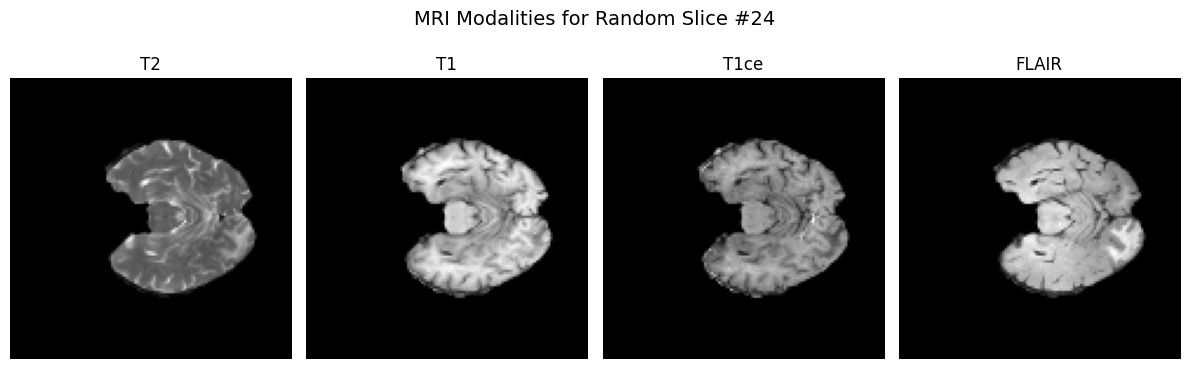

In [13]:
#import matplotlib.pyplot as plt
#import numpy as np
#import random

# Choose a random index from X_train
rand_idx = random.randint(0, X_train.shape[0] - 1)

# Extract the slice (shape: 120x120x4)
sample = X_train_main[rand_idx]

# Modality labels for display
modality_names = ['T2', 'T1', 'T1ce', 'FLAIR']  # Matches your `chanNames` order

# Plot all 4 modalities
plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(sample[:, :, i], cmap='gray')
    plt.title(modality_names[i])
    plt.axis('off')
plt.suptitle(f'MRI Modalities for Random Slice #{rand_idx}', fontsize=14)
plt.tight_layout()
plt.show()


# Data Augumentation

In [14]:
def brain_seg_Augmentation(inpImm, segMask):
    # Random spatial roll
    roll = tf.random.uniform(shape=(2,), minval=-3, maxval=3, dtype=tf.int32)
    inpImm = tf.roll(inpImm, shift=roll, axis=[0, 1])
    segMask = tf.roll(segMask, shift=roll, axis=[0, 1])

    # Random horizontal and vertical flips
    flip_h = tf.random.uniform(()) > 0.5
    flip_v = tf.random.uniform(()) > 0.5
    if flip_h:
        inpImm = tf.reverse(inpImm, axis=[1])
        segMask = tf.reverse(segMask, axis=[1])
    if flip_v:
        inpImm = tf.reverse(inpImm, axis=[0])
        segMask = tf.reverse(segMask, axis=[0])

    # Random intensity scaling (multiplicative)
    scale = tf.random.normal(shape=(), mean=1.0, stddev=0.07)
    inpImm = inpImm * scale

    # Random brightness adjustment
    inpImm = tf.image.random_brightness(inpImm, max_delta=0.1)

    # Contrast adjustment
    contrast_factor = tf.random.uniform(shape=(), minval=0.8, maxval=1.2)
    inpImm = tf.image.adjust_contrast(inpImm, contrast_factor)

    return inpImm, segMask



# Apply augmentation
X_train_aug, y_train_aug = brain_seg_Augmentation(X_aug, y_aug)

#concatenate to original
X_train_tot = np.concatenate([y_train_main, X_train_aug])
y_train_tot = np.concatenate([y_train_main, y_train_aug])

X_train_total = np.concatenate([y_train_tot, X_aug])
y_train_total = np.concatenate([y_train_tot, y_aug])


In [15]:
print(X_train_total.shape)

(5313, 120, 120, 4)


In [16]:
print(X_train_tot.shape)

(3542, 120, 120, 4)


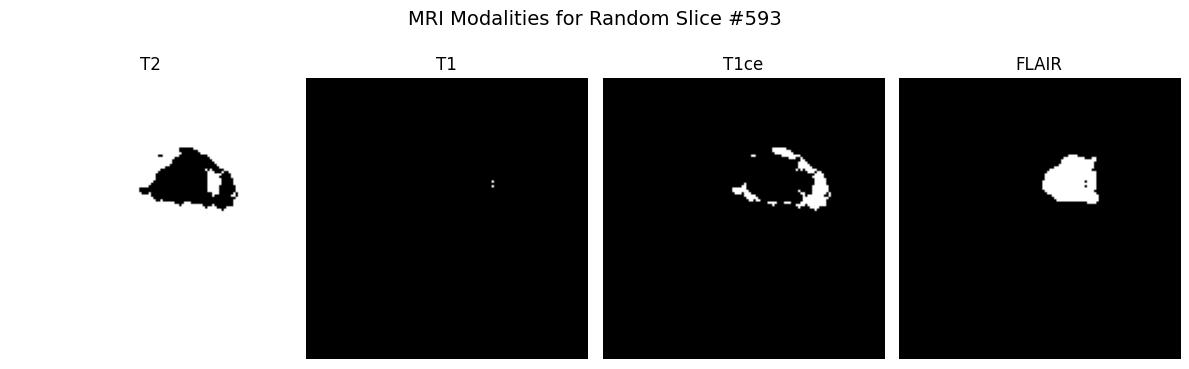

In [40]:
#import matplotlib.pyplot as plt
#import numpy as np
#import random

# Choose a random index from X_train
rand_idx = random.randint(0, X_aug.shape[0] - 1)

# Extract the slice (shape: 120x120x4)
sample = X_train_total[rand_idx]

# Modality labels for display
modality_names = ['T2', 'T1', 'T1ce', 'FLAIR']  # Matches your `chanNames` order

# Plot all 4 modalities
plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(sample[:, :, i], cmap='gray')
    plt.title(modality_names[i])
    plt.axis('off')
plt.suptitle(f'MRI Modalities for Random Slice #{rand_idx}', fontsize=14)
plt.tight_layout()
plt.show()

In [41]:
X_train_aug.shape[0]

1771

In [42]:
y_train_total.shape[0]

5313

### Normal Unet

In [43]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Conv2DTranspose, concatenate
from tensorflow.keras.initializers import HeNormal

In [ ]:
immV.shape[1]

120

In [ ]:
immV.shape[2]

120

In [ ]:
nChan

4

In [44]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Dropout
from tensorflow.keras.models import Model

# Assume your input data has shape (batch_size, height, width, channels)
# Replace these with your actual variables
input_shape = (120, 120, 4)  # Example: input shape of each MRI slice
inputL = Input(shape=input_shape)

# Encoder
c1 = Conv2D(16, 3, activation='relu', padding='same')(inputL)
c2 = Conv2D(16, 3, activation='relu', padding='same')(c1)
c2 = Dropout(0.2)(c2)

c3 = MaxPooling2D()(c2)
c4 = Conv2D(32, 3, activation='relu', padding='same')(c3)
c5 = Conv2D(32, 3, activation='relu', padding='same')(c4)
c5 = Dropout(0.2)(c5)

c6 = MaxPooling2D()(c5)
c7 = Conv2D(64, 3, activation='relu', padding='same')(c6)
c8 = Conv2D(64, 3, activation='relu', padding='same')(c7)
c8 = Dropout(0.3)(c8)

c9 = MaxPooling2D()(c8)

# Bridge
c10 = Conv2D(128, 3, activation='relu', padding='same')(c9)
c11 = Conv2D(128, 3, activation='relu', padding='same')(c10)
c12 = Conv2D(128, 3, activation='relu', padding='same')(c11)
c12 = Dropout(0.4)(c12)

# Decoder
c13 = UpSampling2D()(c12)
c14 = concatenate([c13, c8])
c15 = Conv2D(64, 3, activation='relu', padding='same')(c14)
c16 = Conv2D(64, 3, activation='relu', padding='same')(c15)
c16 = Dropout(0.3)(c16)

c17 = UpSampling2D()(c16)
c18 = concatenate([c17, c5])
c19 = Conv2D(32, 3, activation='relu', padding='same')(c18)
c20 = Conv2D(32, 3, activation='relu', padding='same')(c19)
c20 = Dropout(0.2)(c20)

c21 = UpSampling2D()(c20)
c22 = concatenate([c21, c2])
c23 = Conv2D(16, 3, activation='relu', padding='same')(c22)
c24 = Conv2D(16, 3, activation='relu', padding='same')(c23)
c24 = Dropout(0.2)(c24)

# Output layer for 4 classes with softmax activation
outL = Conv2D(4, 1, activation='softmax', padding='same')(c24)

# Define the model
model1 = Model(inputs=inputL, outputs=outL)

# Summary
model1.summary()


# Summary
model1.summary()
print(model1.input_shape)
print(model1.output_shape)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 120, 120,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 120, 120,  │        592 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 120, 120,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 120, 120,  │          0 │ conv2d_1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 60, 60,    │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 60, 60,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 60, 60,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 60, 60,    │          0 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ dropout_1[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 30, 30,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 30, 30,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 30,    │          0 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 15, 15,    │          0 │ dropout_2[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 15, 15,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 15, 15,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 15, 15,    │    147,584 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 15, 15,    │          0 │ conv2d_8[0][0]  

 Total params: 635,076 (2.42 MB)

 Trainable params: 635,076 (2.42 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 120, 120,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 120, 120,  │        592 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 120, 120,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 120, 120,  │          0 │ conv2d_1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 60, 60,    │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 60, 60,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 60, 60,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 60, 60,    │          0 │ conv2d_3[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ dropout_1[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 30, 30,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 30, 30,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 30,    │          0 │ conv2d_5[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 15, 15,    │          0 │ dropout_2[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 15, 15,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 15, 15,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 15, 15,    │    147,584 │ conv2d_7[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 15, 15,    │          0 │ conv2d_8[0][0]  

 Total params: 635,076 (2.42 MB)

 Trainable params: 635,076 (2.42 MB)

 Non-trainable params: 0 (0.00 B)

(None, 120, 120, 4)
(None, 120, 120, 4)


## Dice accuracy

In [45]:
from tensorflow.python.ops import math_ops
def dice_accuracy(y_true, y_pred):

# Ignores the background class (class 0) by selecting only classes 1 to 3.
# Converts both y_true and y_pred to binary masks (0 or 1) by applying a threshold of 0.5.
# Uses math_ops.cast(..., y_pred.dtype) to ensure the same data type as predictions.
  y_true = math_ops.cast(y_true[:,:,:,1:] > 0.5, y_pred.dtype)
  y_pred = math_ops.cast(y_pred[:,:,:,1:] > 0.5, y_pred.dtype)
  intersec = y_true*y_pred
  union = y_true+y_pred
#  print(K.sum(intersec,axis=[1,2]))
  dicePat = (1+2*K.sum(intersec,axis=[1,2]))/(1+K.sum(union,axis=[1,2]))
#  print(dicePat.eval)
  return K.mean(dicePat)


In [46]:
optim = optimizers.Adam(learning_rate=1e-3)
model1.compile(optimizer=optim,loss='categorical_crossentropy',metrics= [dice_accuracy])

In [47]:
fitHist = model1.fit(X_train_total,y_train_total,validation_data=(X_test,y_test),batch_size=8,epochs=35) # cnn without residual block with contrast dat aug

Epoch 1/35
665/665 ━━━━━━━━━━━━━━━━━━━━ 37s 33ms/step - dice_accuracy: 0.3660 - loss: 0.1084 - val_dice_accuracy: 0.6823 - val_loss: 0.0346
Epoch 2/35
665/665 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - dice_accuracy: 0.8475 - loss: 0.0136 - val_dice_accuracy: 0.7285 - val_loss: 0.0347
Epoch 3/35
665/665 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - dice_accuracy: 0.8715 - loss: 0.0106 - val_dice_accuracy: 0.7442 - val_loss: 0.0342
Epoch 4/35
665/665 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - dice_accuracy: 0.8624 - loss: 0.0135 - val_dice_accuracy: 0.7536 - val_loss: 0.0445
Epoch 5/35
665/665 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - dice_accuracy: 0.9011 - loss: 0.0078 - val_dice_accuracy: 0.7757 - val_loss: 0.0381
Epoch 6/35
665/665 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - dice_accuracy: 0.9057 - loss: 0.0067 - val_dice_accuracy: 0.7791 - val_loss: 0.0366
Epoch 7/35
665/665 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - dice_accuracy: 0.9117 - loss: 0.0062 - val_dice_accuracy: 0.7238 - val_loss: 0.0380
Epoch 8/35
665/665 ━

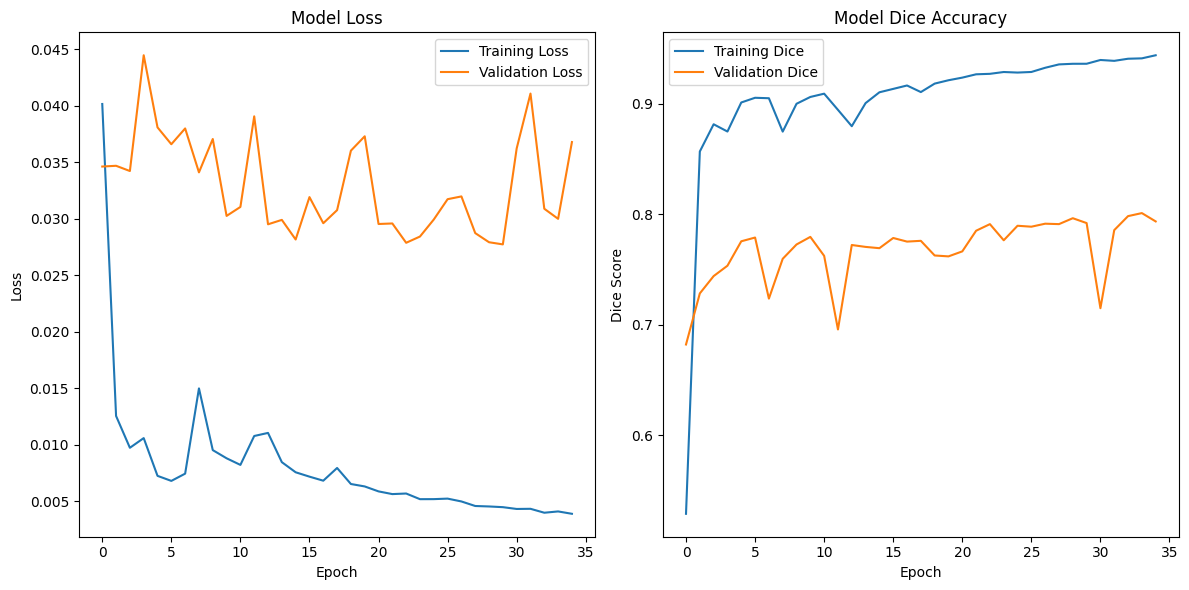

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Loss Plot
plt.subplot(121)
plt.plot(fitHist.history['loss'], label='Training Loss')
plt.plot(fitHist.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Dice Accuracy Plot
plt.subplot(122)
plt.plot(fitHist.history['dice_accuracy'], label='Training Dice')
plt.plot(fitHist.history['val_dice_accuracy'], label='Validation Dice')
plt.title('Model Dice Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Dice Score')
plt.legend()

plt.tight_layout()
plt.show()


In [49]:
def diceFromMap(map1,map2):
    unionLab = np.sum(map1) +np.sum(map2)
    interLab = np.sum(map1 & map2, dtype=np.float32)
    return (2*interLab+.1)/(unionLab+.1)
def computeDices (yPred,yTrue):
    yPred = np.asarray(yPred)
    yTrue = np.asarray(yTrue)
    if np.sum(yTrue[:,:,:,1:])<1:
        return(np.nan,np.nan,np.nan)
    diceWhole = diceFromMap(np.sum(yPred[:,:,:,1:],axis=-1)>np.sum(yPred[:,:,:,:1],axis=-1),
                            np.sum(yTrue[:,:,:,1:],axis=-1)>np.sum(yTrue[:,:,:,:1],axis=-1))
    diceCore = diceFromMap(np.sum(yPred[:,:,:,2:],axis=-1)>np.sum(yPred[:,:,:,:2],axis=-1),
                           np.sum(yTrue[:,:,:,2:],axis=-1)>np.sum(yTrue[:,:,:,:2],axis=-1))
    diceEnh = diceFromMap(np.sum(yPred[:,:,:,3:],axis=-1)>np.sum(yPred[:,:,:,:3],axis=-1),
                          np.sum(yTrue[:,:,:,3:],axis=-1)>np.sum(yTrue[:,:,:,:3],axis=-1))
    return (diceWhole,diceCore,diceEnh)

In [50]:
# You assume each test patient has 77 slices.
# You run predictions slice-wise per patient and store the three Dice scores for each in diceV.

nTestPat = 20
diceV = np.zeros((20,3))
for idx in range(20):
    yPred = model1(X_test[idx*77:(idx+1)*77,:,:,:])
    diceV[idx,:]=np.array(computeDices(yPred,y_test[idx*77:(idx+1)*77,:,:,:]))

Whole Dice: mean = 79.9% Median = 89.1%
Core Dice: mean = 65.4% Median = 68.4%
Active Dice: mean = 49.1% Median = 54.6%


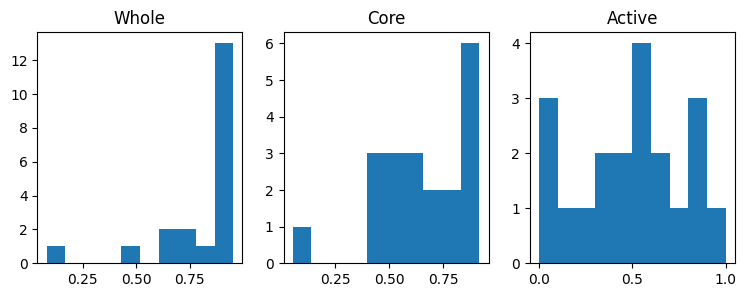

In [51]:
plt.figure(figsize=(9,3))
titleList = ['Whole','Core','Active']
for i in range(3):
    plt.subplot(1,3,i+1)
    _=plt.hist(diceV[:,i])
    plt.title(titleList[i])
for i in range(3):
    outStr = titleList[i] + ' Dice: mean = {:.1f}% Median = {:.1f}%'
    print(outStr.format(np.mean(diceV[:,i]*100),np.median(diceV[:,i]*100)))

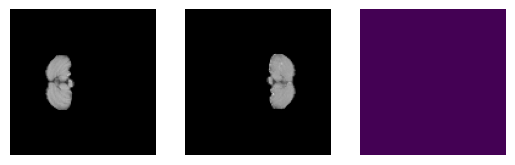

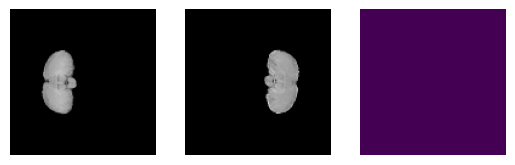

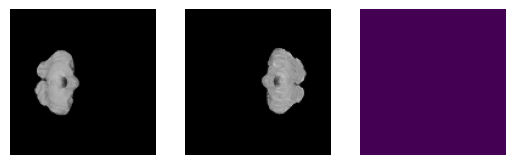

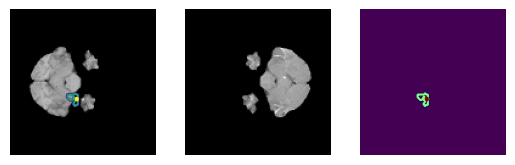

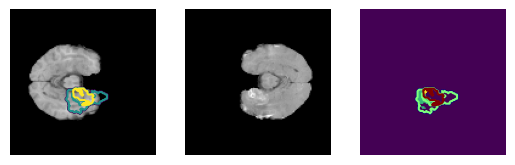

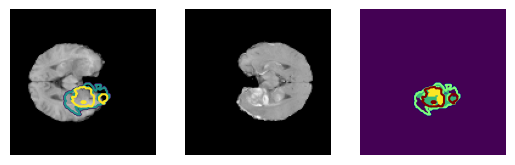

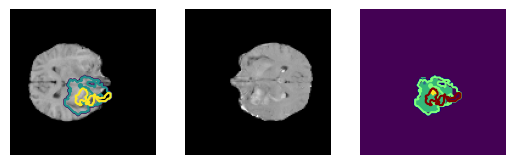

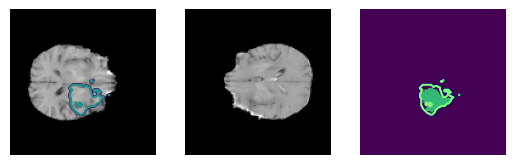

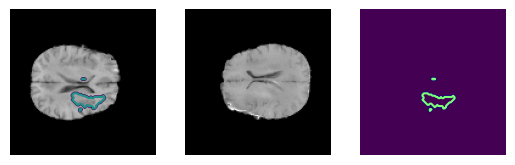

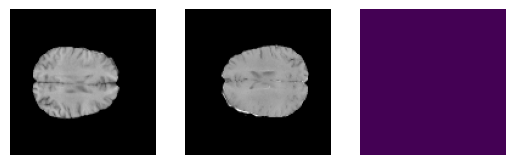

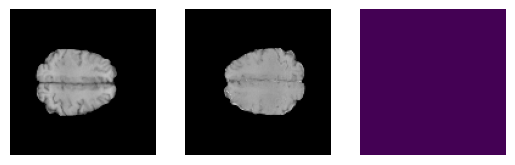

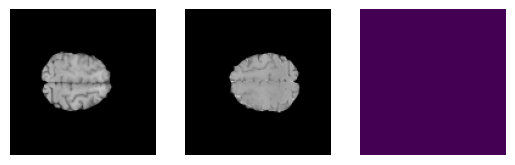

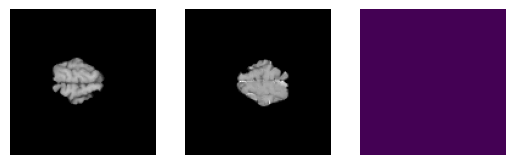

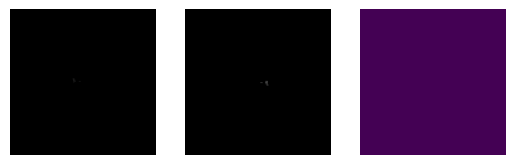

In [52]:
patIdx = 1
slStart = 3
slStop = 70
slStep = 5

yPred = np.array(model1(X_test[(patIdx*77):((patIdx+1)*77),:,:,:]))
yPred = np.argmax(yPred,axis=-1)
yTrue = y_test[(patIdx*77):((patIdx+1)*77),:,:,:]
yTrue = np.argmax(yTrue,axis=-1)
for slIdx in range(slStart,slStop,slStep):
    plt.figure()
    plt.subplot(131)
    # Left – Flair Image + Ground Truth Segmentation Contours
    #  Helps you locate the actual tumor on the scan and visually understand the ground truth labels.
    plt.imshow(np.flip(X_test[patIdx*77+slIdx,:,:,1]),vmin=-0.3,vmax=1.0,cmap='gray')
    plt.contour(yTrue[slIdx,:,:],[0.5,1.5,2.5])
    plt.axis('off')
    plt.subplot(132)
    # Middle – Second MRI Modality (e.g., T1 or T2)
    plt.imshow(X_test[patIdx*77+slIdx,:,:,2],vmin=-0.3,vmax=1.0,cmap='gray')
    plt.axis('off')
  #  plt.contour(yTrue[slIdx,:,:],[0.5,1.5,2.5])
    plt.subplot(133)
    plt.imshow(yPred[slIdx,:,:],vmin=0,vmax=3)
    # Right – Predicted Segmentation + Ground Truth Contours
    # Shows what the model thinks are the tumor regions.
    plt.contour(yTrue[slIdx,:,:],[0.5,1.5,2.5],cmap='jet')
    plt.axis('off')